In [2]:
# importing the necessary libraries
import requests
import pandas as pd
import numpy as np
import os
import praw
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from dotenv import load_dotenv
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Setting up the API and Pulling the Data(Posts) from Reddit

In [ ]:
load_dotenv(dotenv_path='../data.env')  # Load environment variables from .env file
client_secret = os.environ.get('client_secret') #getting my secret from the .env file
client_id = os.environ.get('client_id') #getting my id from the .env file

In [ ]:
reddit = praw.Reddit(
    client_id=client_id,
    client_secret=client_secret,
    user_agent='AltSchool A/B test',    
)

In [5]:
# pulling the data from the reddit
subreddit = reddit.subreddit('apple')
posts = []
for post in subreddit.top(limit=1000):
    posts.append(
        {
            'title': post.title,
            'score': post.score,
            'score_ratio': post.upvote_ratio,
            'spoiler': post.spoiler,
            'over_18': post.over_18,
            'self_post': post.is_self,
            'edited': post.edited,
            'locked': post.locked,
            'num_comments': post.num_comments,
            'created_utc': post.created_utc,
            'url': post.url,
            'id': post.id,
            'author': post.author.name if post.author else None,
        }
    )

In [6]:
#confirming the number of posts pulled
len(posts)

948

In [7]:
#defining a function to create the dataframe
def create_df(posts):
    df = pd.DataFrame(posts)
    df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')
    df['day'] = df['created_utc'].dt.date
    df['hour'] = df['created_utc'].dt.hour
    df.sort_values(by='day', ascending=False, inplace=True)
    return df   

In [8]:
df = create_df(posts)

In [9]:
#Storing the dataframe to a csv file to avoid making to many api calls
df.to_csv('../data/apple_posts.csv', index=False)

In [10]:
df = pd.read_csv('../data/apple_posts.csv', parse_dates=['created_utc'])
df['day'] = pd.to_datetime(df['created_utc']).dt.date
df['title_length'] = df['title'].apply(lambda x: len(x.split()))

In [11]:
df.head()

,title,score,score_ratio,spoiler,over_18,self_post,edited,locked,num_comments,created_utc,url,id,author,day,hour,title_length
0,Pope Leo XIV wears Apple Watch in first offici...,4605,0.90,False,False,False,False,False,283,2025-05-10 18:51:40,https://9to5mac.com/2025/05/10/pope-wears-appl...,1kjhfhv,Nicolapps,2025-05-10,18,10
1,A 'US-Made iPhone' Is Pure Fantasy,5843,0.95,False,False,False,False,False,532,2025-04-08 16:36:21,https://www.404media.co/a-us-made-iphone-is-pu...,1juhzp7,favicondotico,2025-04-08,16,6
2,Apple is racing to fly planes of iPhones into ...,7783,0.97,False,False,False,False,False,562,2025-04-07 19:40:56,https://9to5mac.com/2025/04/07/iphone-inventor...,1jtu9k4,spearson0,2025-04-07,19,15
3,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13569,0.94,False,False,False,False,False,1375,2025-04-04 16:50:10,https://www.macrumors.com/2025/04/04/2300-doll...,1jrgmvl,Drtysouth205,2025-04-04,16,14
4,Apple loses $250bn in market value from Trump ...,6927,0.96,False,False,False,False,False,447,2025-04-03 16:42:53,https://www.ft.com/content/dd2e71bf-e5f5-4ab6-...,1jqncyn,Sheeraz-9,2025-04-03,16,10


# Assigning A/B groups based on sentiment

In [12]:
# Applying sentiment analysis to get new column classification;
sia = SentimentIntensityAnalyzer()
df['sentiment'] = df['title'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [13]:
# defining the function for the grouping   
def groups(score):
    return 'A' if score > 0 else 'B' 


In [14]:
df['ab_group'] = df['sentiment'].apply(groups) # applying the function to the sentiment column

In [15]:
# previewing the grouped data counts
df.loc[:,'ab_group'].value_counts()

ab_group
B    683
A    265
Name: count, dtype: int64

# Data Cleaning and Exploratory Data Analysis on the Data Frame

In [16]:
df.head()

,title,score,score_ratio,spoiler,over_18,self_post,edited,locked,num_comments,created_utc,url,id,author,day,hour,title_length,sentiment,ab_group
0,Pope Leo XIV wears Apple Watch in first offici...,4605,0.90,False,False,False,False,False,283,2025-05-10 18:51:40,https://9to5mac.com/2025/05/10/pope-wears-appl...,1kjhfhv,Nicolapps,2025-05-10,18,10,-0.3612,B
1,A 'US-Made iPhone' Is Pure Fantasy,5843,0.95,False,False,False,False,False,532,2025-04-08 16:36:21,https://www.404media.co/a-us-made-iphone-is-pu...,1juhzp7,favicondotico,2025-04-08,16,6,0.0000,B
2,Apple is racing to fly planes of iPhones into ...,7783,0.97,False,False,False,False,False,562,2025-04-07 19:40:56,https://9to5mac.com/2025/04/07/iphone-inventor...,1jtu9k4,spearson0,2025-04-07,19,15,0.0000,B
3,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13569,0.94,False,False,False,False,False,1375,2025-04-04 16:50:10,https://www.macrumors.com/2025/04/04/2300-doll...,1jrgmvl,Drtysouth205,2025-04-04,16,14,0.0000,B
4,Apple loses $250bn in market value from Trump ...,6927,0.96,False,False,False,False,False,447,2025-04-03 16:42:53,https://www.ft.com/content/dd2e71bf-e5f5-4ab6-...,1jqncyn,Sheeraz-9,2025-04-03,16,10,0.0258,A


In [17]:
df.columns

Index(['title', 'score', 'score_ratio', 'spoiler', 'over_18', 'self_post',
       'edited', 'locked', 'num_comments', 'created_utc', 'url', 'id',
       'author', 'day', 'hour', 'title_length', 'sentiment', 'ab_group'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   title         948 non-null    object        
 1   score         948 non-null    int64         
 2   score_ratio   948 non-null    float64       
 3   spoiler       948 non-null    bool          
 4   over_18       948 non-null    bool          
 5   self_post     948 non-null    bool          
 6   edited        948 non-null    object        
 7   locked        948 non-null    bool          
 8   num_comments  948 non-null    int64         
 9   created_utc   948 non-null    datetime64[ns]
 10  url           948 non-null    object        
 11  id            948 non-null    object        
 12  author        865 non-null    object        
 13  day           948 non-null    object        
 14  hour          948 non-null    int64         
 15  title_length  948 non-null    int64     

In [19]:
df.describe(include = 'all')

,title,score,score_ratio,spoiler,over_18,self_post,edited,locked,num_comments,created_utc,url,id,author,day,hour,title_length,sentiment,ab_group
count,948,948.000000,948.000000,948,948,948,948,948,948.000000,948,948,948,865,948,948.000000,948.000000,948.000000,948
unique,948,NaN,NaN,1,1,2,77,2,NaN,NaN,947,948,551,856,NaN,NaN,NaN,2
top,Pope Leo XIV wears Apple Watch in first offici...,NaN,NaN,False,False,False,False,False,NaN,NaN,https://www.apple.com/shop/product/MW693AM/A/p...,1kjhfhv,aaronp613,2017-11-03,NaN,NaN,NaN,B
freq,1,NaN,NaN,948,948,803,872,928,NaN,NaN,2,1,40,3,NaN,NaN,NaN,683
mean,NaN,7924.300633,0.928681,NaN,NaN,NaN,NaN,NaN,1151.918776,2020-07-18 14:07:32.188818944,NaN,NaN,NaN,NaN,13.795359,14.503165,0.018722,NaN
min,NaN,3994.000000,0.640000,NaN,NaN,NaN,NaN,NaN,1.000000,2014-09-09 22:14:18,NaN,NaN,NaN,NaN,0.000000,1.000000,-0.926000,NaN
25%,NaN,4684.750000,0.910000,NaN,NaN,NaN,NaN,NaN,412.750000,2019-03-07 13:23:12.500000,NaN,NaN,NaN,NaN,11.000000,10.000000,-0.058000,NaN
50%,NaN,5811.500000,0.940000,NaN,NaN,NaN,NaN,NaN,648.000000,2020-09-03 20:41:59,NaN,NaN,NaN,NaN,14.500000,13.000000,0.000000,NaN
75%,NaN,8470.000000,0.960000,NaN,NaN,NaN,NaN,NaN,1092.750000,2021-08-06 17:38:02,NaN,NaN,NaN,NaN,18.000000,16.000000,0.177900,NaN
max,NaN,71175.000000,0.990000,NaN,NaN,NaN,NaN,NaN,85786.000000,2025-05-10 18:51:40,NaN,NaN,NaN,NaN,23.000000,55.000000,0.959500,NaN


In [20]:
df.loc[:,'edited'].value_counts()

edited
False           872
1530455026.0      1
1518118766.0      1
1520236598.0      1
1522392216.0      1
               ... 
1559234958.0      1
1563677686.0      1
1563736060.0      1
1565270901.0      1
1414601511.0      1
Name: count, Length: 77, dtype: int64

In [21]:
# replacing numneric values with boolean values in the edited column
df['edited'] = df['edited'].apply(lambda x: True if x else False)

In [22]:
df.loc[:,'edited'].value_counts()

edited
True    948
Name: count, dtype: int64

In [23]:
# previewing the spoiler and over_18 columns
df.loc[:,['spoiler', 'over_18']].value_counts()

spoiler  over_18
False    False      948
Name: count, dtype: int64

In [24]:
df.loc[:,'ab_group'].value_counts()

ab_group
B    683
A    265
Name: count, dtype: int64

In [25]:
# dropping the columns that are not needed for the analysis
df.drop(columns = ['spoiler', 'over_18'], inplace=True)

In [26]:
# dropping other columns that are not needed for the analysis
df.drop(columns = ['created_utc', 'url', 'id'], inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         948 non-null    object 
 1   score         948 non-null    int64  
 2   score_ratio   948 non-null    float64
 3   self_post     948 non-null    bool   
 4   edited        948 non-null    bool   
 5   locked        948 non-null    bool   
 6   num_comments  948 non-null    int64  
 7   author        865 non-null    object 
 8   day           948 non-null    object 
 9   hour          948 non-null    int64  
 10  title_length  948 non-null    int64  
 11  sentiment     948 non-null    float64
 12  ab_group      948 non-null    object 
dtypes: bool(3), float64(2), int64(4), object(4)
memory usage: 77.0+ KB


In [28]:
# saving the cleaned dataframe to a csv file
df.to_csv('../data/apple_posts_cleaned.csv', index=False)

In [3]:
df = pd.read_csv('../data/apple_posts_cleaned.csv', parse_dates=['day'])
df['day'] = pd.to_datetime(df['day'])

In [7]:
df['ab_group'].value_counts()

ab_group
B    683
A    265
Name: count, dtype: int64

In [30]:
df[df['author'].isna() == True]['ab_group'].value_counts()

ab_group
B    62
A    21
Name: count, dtype: int64

we have a small number of undntified authors in each group, so we drop them

In [14]:
df.dropna(subset=['author'], inplace=True)  # Dropping rows where author is NaN

In [15]:
df[df['author'].isna() == True]['ab_group'].value_counts()

Series([], Name: count, dtype: int64)

In [16]:
groups = df.groupby('ab_group')[['num_comments', 'score', 'title_length']].describe()

## Comments

In [46]:
mean_comments = df['num_comments'].mean()
mean_comments

1174.4416184971099

In [17]:
groups['num_comments']

,count,mean,std,min,25%,50%,75%,max
ab_group,,,,,,,,
A,244.0,1817.950820,9251.103183,78.0,380.75,605.0,999.0,85786.0
B,621.0,921.597424,898.580742,1.0,415.00,649.0,1101.0,7730.0


* Despite more posts in group 'B' than in 'A', 'A' has a higher mean number of comments

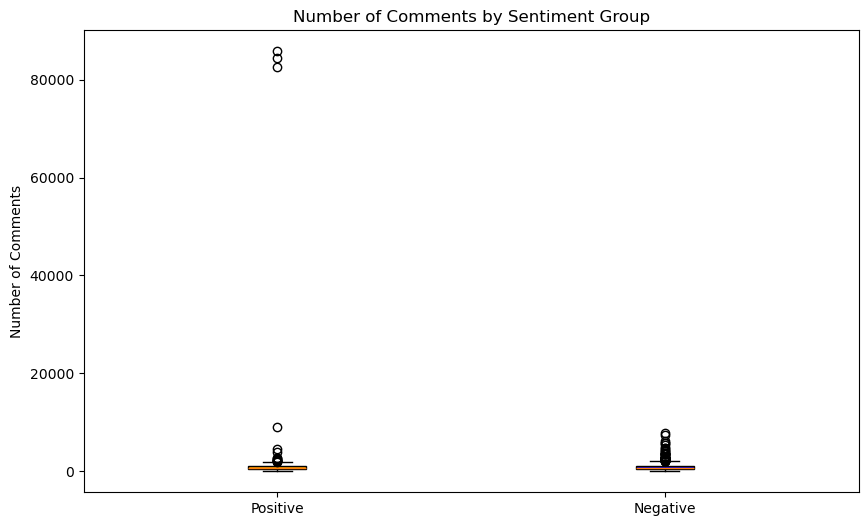

In [18]:
ab_comments = [np.array(df[df['ab_group'] == 'A']['num_comments']),
               np.array(df[df['ab_group'] == 'B']['num_comments'])] # I created an array of the comments for each group
labels = ['Positive','Negative']
colours = ['orange', 'blue']
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_ylabel('Number of Comments')
bplot= ax.boxplot(ab_comments,
                  patch_artist=True, #for coloring the boxes
                  tick_labels=labels,) 
for patch, color in zip(bplot['boxes'], colours):
    patch.set_facecolor(color)
plt.title('Number of Comments by Sentiment Group')
plt.show()

the boxplot is visually distorted because of the extreme outliers 

so, I will remove statistical outliers for our boxplot visualization

In [19]:
def clean_outliers(series): # function to clean outliers from a series
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series[(series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)]

In [20]:
df['clean_comments'] = df.groupby('ab_group')['num_comments'].transform(clean_outliers)

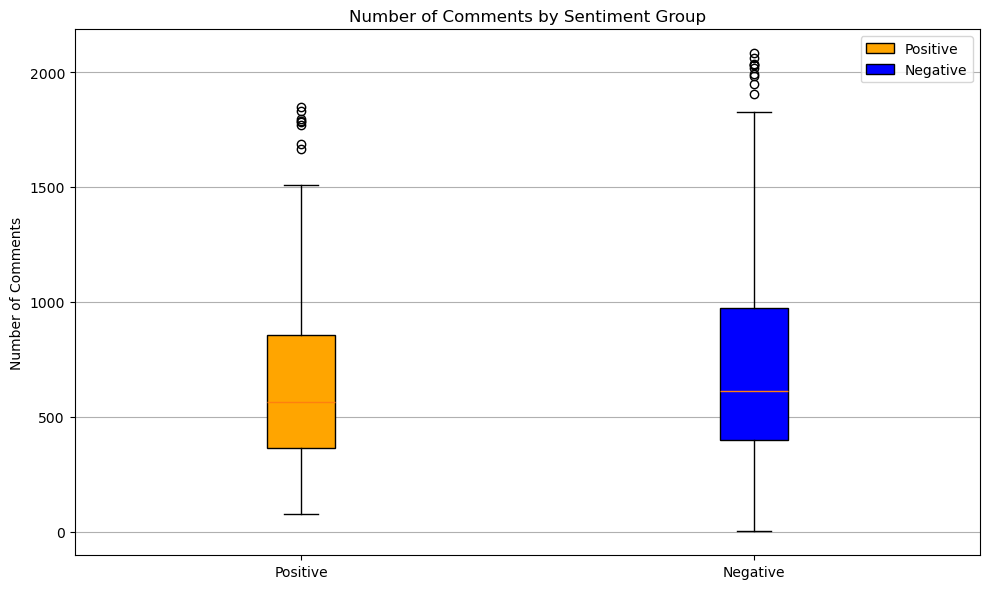

In [49]:
# visualizing the boxplots for comments(again)
ab_comments = [np.array(df[df['ab_group'] == 'A']['clean_comments'].dropna()),
               np.array(df[df['ab_group'] == 'B']['clean_comments'].dropna())] 
labels = ['Positive','Negative']
colours = ['orange', 'blue']
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_ylabel('Number of Comments')
bplot= ax.boxplot(ab_comments,
                  patch_artist=True, #for coloring the boxes
                  tick_labels=labels,) 
for patch, color in zip(bplot['boxes'], colours):
    patch.set_facecolor(color)
plt.title('Number of Comments by Sentiment Group')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(handles=[bplot["boxes"][0], bplot["boxes"][1]], labels=labels, loc='upper right')
plt.show()

Now we have a clearer graphical view of the comment distribution across the groups.

We see that across both groups the comments are positively skewed; this means:

• majority of posts receive fewer comments, while a small number of posts receive a disproportionately high number of comments.
•the average number of comments is affected by those high values

thus we can conclude; while most posts don't generate lots of comments, the highly popular/controversal ones do

## Score

In [48]:
mean_score = df['score'].mean()
mean_score

7847.750289017341

In [22]:
groups['score']

,count,mean,std,min,25%,50%,75%,max
ab_group,,,,,,,,
A,244.0,7191.090164,5409.038414,4004.0,4612.5,5718.5,7657.75,64932.0
B,621.0,8105.761675,6781.692951,3994.0,4685.0,5762.0,8600.00,71175.0


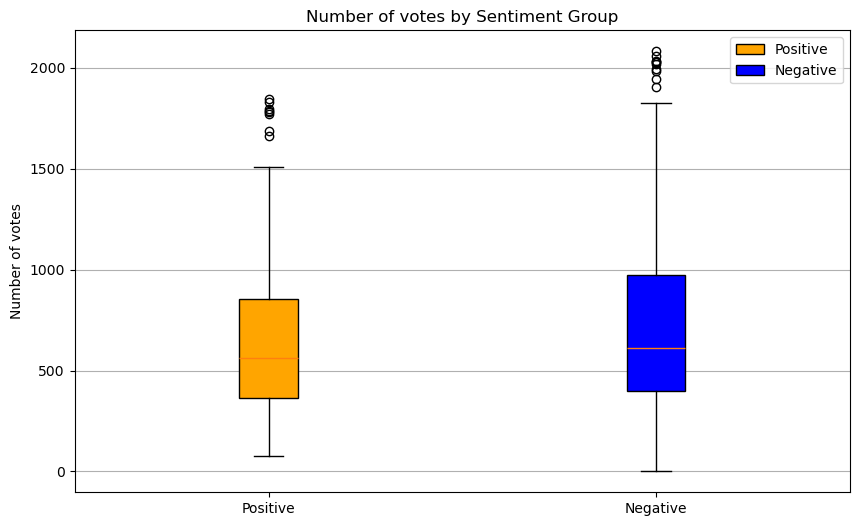

In [52]:
ab_scores = [np.array(df[df['ab_group'] == 'A']['score']),
               np.array(df[df['ab_group'] == 'B']['score'])] # I created an array of the comments for each group
labels = ['Positive','Negative']
colours = ['orange', 'blue']
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_ylabel('Number of votes')
bplot= ax.boxplot(ab_comments,
                  patch_artist=True, #for coloring the boxes
                  tick_labels=labels,) 
for patch, color in zip(bplot['boxes'], colours):
    patch.set_facecolor(color)
plt.title('Number of votes by Sentiment Group')
plt.legend(handles=[bplot["boxes"][0], bplot["boxes"][1]], labels=labels, loc='upper right')
plt.grid(axis='y')
plt.show()

The boxplot shows the scores(upvotes) for each group is positively skewed.

• most posts don't get a lot of engagement. However, a small number of posts are exceptionally popular or engaging, leading to a higher count of upvotes.



## Title Length

In [47]:
mean_title_length = df['title_length'].mean()
mean_title_length

14.531791907514451

In [24]:
groups['title_length']

,count,mean,std,min,25%,50%,75%,max
ab_group,,,,,,,,
A,244.0,18.479508,11.751700,2.0,11.0,14.0,21.25,55.0
B,621.0,12.980676,6.005343,1.0,10.0,12.0,15.00,54.0


Title length is longer in group 'A' than in group 'B'

In [25]:
groups['title_length']['mean']

ab_group
A    18.479508
B    12.980676
Name: mean, dtype: float64

We observe the average length of titles for posts in group 'A' and 'B' are 18 and 13 respectively

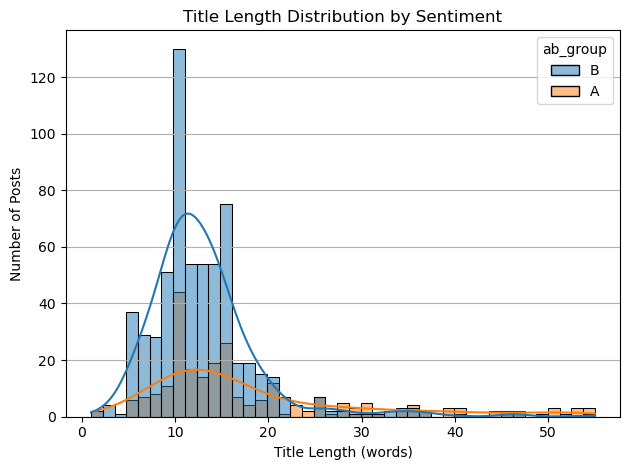

<Figure size 1000x600 with 0 Axes>

In [26]:
sns.histplot(data=df, x='title_length', hue='ab_group', kde=True)
plt.title("Title Length Distribution by Sentiment")
plt.ylabel("Number of Posts")
plt.xlabel("Title Length (words)")
plt.grid(axis='y')
plt.tight_layout()
plt.figure(figsize=(10, 6))
plt.show()

# A/B testing 

Performing a t-test to see if the the mean post scores(upvotes) and sentiment are statisticaly significant 

In [27]:
# getting the cores for each group
group_a_scores = df[df['ab_group'] == 'A']['score']
group_b_scores = df[df['ab_group'] == 'B']['score']

In [28]:
t_stat, p_value = ttest_ind(group_a_scores, group_b_scores, equal_var=False)
print(f'T-Statistic: {t_stat:.3f}')
print(f'P-Value: {p_value:.3f}')

T-Statistic: -2.077
P-Value: 0.038


In [29]:
group_a_comments = df[df['ab_group'] == 'A']['num_comments'].dropna() 
group_b_comments = df[df['ab_group'] == 'B']['num_comments'].dropna()

In [31]:

t_stat, p_value = ttest_ind(group_a_comments, group_b_comments, equal_var=False)
print(f'T-Statistic: {t_stat:.3f}')
print(f'P-Value: {p_value:.3f}')

T-Statistic: 1.511
P-Value: 0.132


| Metric       | t-stat | p-value | Interpretation                       |
| ------------ | ------ | ------- | ------------------------------------ |
| **Score**    | –2.077 | 0.038   | p < 0.05 → Significant difference    |
| **Comments** | 1.510  | 0.132   | p ≥ 0.05 → No significant difference |


# Drawing Conclusion

## Score

Since our P-value(0.038) is slightly below the 0.05 threshold, it indicates the difference is statistically significant at the 5% level

Thus, we reject our null hypothesis and conclude that there may be a meaningful difference between title sentiment and voting behaviour - even though the effect size is small

## Comments

Since our P-value(0.132) is way above the 0.05 threshold, we cannot reject our null hypothesis, which means the title sentiment does not affect the amount of comments. 

Summary Insights located in the document: https://docs.google.com/document/d/18SMNAAgXsdKh1IAyNmC_88nlVzBtzC1B4b4qlyMd30E/edit?usp=sharing